# Simulation Pipeline — Semivariogram Regularizer Downscaling Project

Generate synthetic spatial fields with a **known** spatial-dependence structure,
so the *true* semivariogram is known by construction. Each fine-resolution field
is coarsened to make a paired **(coarse → fine)** example. Because we defined the
generating process, we can later test whether a model (with vs. without the
semivariogram regularizer) recovers the known spatial structure.

**Pipeline per sample**
1. Draw a fine field from a Matérn Gaussian random field.
2. Coarsen it (block-average) to make the coarse input.
3. Build a short temporal stack of coarse grids per target.

The notebook also runs a **sanity check**: estimate the empirical semivariogram
of generated fields and refit the model, confirming the recovered parameters
match what we asked for.

## Setup

Requires `numpy`, `gstools`, `matplotlib`. Uncomment to install if needed.

In [2]:
# !pip install numpy gstools matplotlib
import numpy as np
import gstools as gs
import matplotlib.pyplot as plt

print("gstools", gs.__version__)

gstools 1.7.0


## Configuration

All knobs in one place. The covariance parameters **are** the ground-truth
semivariogram:

| param | meaning |
|-------|---------|
| `var` | sill (overall variance / plateau) |
| `len_scale` | range (distance over which points stay correlated), in pixels |
| `nu` | Matérn smoothness (roughness of the field) |
| `nugget` | tiny-scale noise (measurement error); `0.0` = none |

**Tip:** keep `len_scale` well under `fine_size`, or the variogram can't be
estimated accurately on a finite grid.

In [3]:
from dataclasses import dataclass

@dataclass
class SimConfig:
    # --- grid ---
    fine_size: int = 240        # fine field is fine_size x fine_size
    coarse_factor: int = 3      # coarse is (fine_size / factor)^2
                                # 128 / 4 = 32x32 coarse -> 128x128 fine

    # --- spatial structure (the known ground truth) ---
    var: float = 2.0            # sill
    len_scale: float = 15.0     # range, in pixels
    nu: float = 0.5             # Matern smoothness
    nugget: float = 0.0         # nugget

    # --- temporal stack ---
    stack_depth: int = 3        # coarse grids per input example (1 = no time)

    # --- dataset size ---
    n_samples: int = 200        # number of (coarse-stack -> fine) examples
                                # ~0.7s per field: 200 x 3 steps is ~7 min

    # --- reproducibility ---
    seed: int = 20240519


def quick_config() -> SimConfig:
    """Small, fast config for development / smoke-testing."""
    return SimConfig(fine_size=64, n_samples=200, stack_depth=3)


cfg = SimConfig()
cfg

SimConfig(fine_size=240, coarse_factor=3, var=2.0, len_scale=15.0, nu=0.5, nugget=0.0, stack_depth=3, n_samples=200, seed=20240519)

## Core generation functions

- `make_model` builds the Matérn model that defines the ground-truth structure.
- `generate_fine_field` draws one fine field on a structured grid.
- `coarsen` block-averages a fine field down to the coarse input. (GSTools has
  no "downscale target" call, so we do this ourselves with a reshape + mean.)

In [4]:
def make_model(cfg: SimConfig) -> gs.Matern:
    """Matern covariance model defining the ground-truth structure."""
    return gs.Matern(
        dim=2, var=cfg.var, len_scale=cfg.len_scale, nu=cfg.nu, nugget=cfg.nugget
    )

def generate_fine_field(model: gs.Matern, size: int, seed: int) -> np.ndarray:
    """Draw one fine-resolution field on a structured grid."""
    srf = gs.SRF(model, seed=seed)
    x = y = np.arange(size)
    field = srf.structured([x, y])          # (size, size)
    return np.asarray(field, dtype=np.float32)


def coarsen(field: np.ndarray, factor: int) -> np.ndarray:
    """Block-average a fine field down by `factor` in each dim (fine -> coarse)."""
    n = field.shape[0]
    assert n % factor == 0, f"grid size {n} not divisible by factor {factor}"
    m = n // factor
    return field.reshape(m, factor, m, factor).mean(axis=(1, 3)).astype(np.float32)

Quick look at a single generated field and its coarsened version:

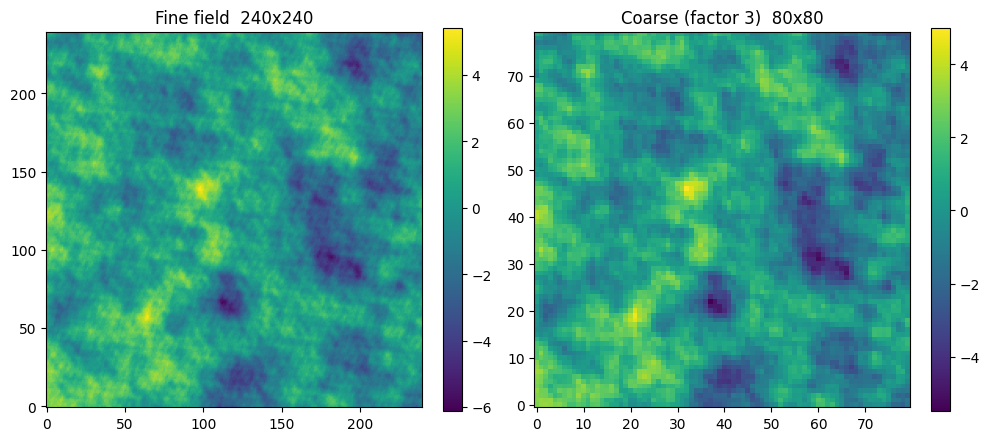

In [5]:
_model = make_model(cfg)
_f = generate_fine_field(_model, cfg.fine_size, seed=cfg.seed)
_c = coarsen(_f, cfg.coarse_factor)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
im0 = ax[0].imshow(_f, origin="lower", cmap="viridis")
ax[0].set_title(f"Fine field  {_f.shape[0]}x{_f.shape[1]}")
plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(_c, origin="lower", cmap="viridis")
ax[1].set_title(f"Coarse (factor {cfg.coarse_factor})  {_c.shape[0]}x{_c.shape[1]}")
plt.colorbar(im1, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## Build the dataset

For a "temporal" stack we generate `stack_depth` fields per sample with
consecutive seeds. These are **independent draws sharing the same spatial
model** — right spatial structure, but *no* real temporal correlation between
steps. That's fine for a first purely-spatial proof of concept. (See the last
cell for how to add genuine temporal correlation.)

Returns:
- `coarse_stacks`: `(n_samples, stack_depth, coarse, coarse)` — the model input
- `fine_targets`: `(n_samples, fine, fine)` — the target (last stack step's fine field)

In [6]:
def build_dataset(cfg: SimConfig):
    model = make_model(cfg)
    coarse = cfg.fine_size // cfg.coarse_factor

    coarse_stacks = np.empty(
        (cfg.n_samples, cfg.stack_depth, coarse, coarse), dtype=np.float32
    )
    fine_targets = np.empty(
        (cfg.n_samples, cfg.fine_size, cfg.fine_size), dtype=np.float32
    )

    seed_counter = cfg.seed
    for i in range(cfg.n_samples):
        fine_steps = []
        for t in range(cfg.stack_depth):
            f = generate_fine_field(model, cfg.fine_size, seed=seed_counter)
            seed_counter += 1
            fine_steps.append(f)
            coarse_stacks[i, t] = coarsen(f, cfg.coarse_factor)
        fine_targets[i] = fine_steps[-1]   # target = last step's fine field

    return coarse_stacks, fine_targets

**Note on runtime:** each 128×128 field takes ~0.7s, so the default
200 samples × 3 steps is several minutes. Use `quick_config()` while developing.

In [7]:
# For a fast first run, swap to quick_config(). Comment out to use full cfg.
run_cfg = SimConfig()

coarse_stacks, fine_targets = build_dataset(run_cfg)
print("coarse_stacks:", coarse_stacks.shape, " (N, T, H, W)")
print("fine_targets :", fine_targets.shape, " (N, H, W)")

coarse_stacks: (200, 3, 80, 80)  (N, T, H, W)
fine_targets : (200, 240, 240)  (N, H, W)


## Sanity check: does the data have the structure we asked for?

The single most important check. Estimate the empirical semivariogram from
generated fields, average over several fields, and refit a Matérn model. The
recovered parameters should match the inputs.

**Two gotchas handled here:**
- Matérn's smoothness `nu` runs away to nonsense if unbounded, so we bound it.
- Recovery is only accurate when `len_scale` is small relative to the grid;
  on a 64-grid a range of 15 is too large, so use the full 128 grid (default
  `SimConfig`) for an accurate check.

In [8]:
def sanity_check_variogram(cfg: SimConfig, n_check: int = 12):
    model = make_model(cfg)
    x = y = np.arange(cfg.fine_size)
    gx, gy = np.meshgrid(x, y, indexing="ij")
    coords = (gx.ravel(), gy.ravel())

    all_gamma = []
    seed = cfg.seed + 10_000
    for _ in range(n_check):
        field = generate_fine_field(model, cfg.fine_size, seed=seed)
        seed += 1
        bin_center, gamma = gs.vario_estimate(
            coords, field.ravel(), sampling_size=3000, sampling_seed=seed
        )
        all_gamma.append(gamma)
    mean_gamma = np.mean(all_gamma, axis=0)

    # bound nu so the fit doesn't run away
    fit = gs.Matern(dim=2)
    fit.set_arg_bounds(nu=[0.2, 5.0])
    fit.fit_variogram(bin_center, mean_gamma, nu=True)

    print("--- Variogram sanity check ---")
    print(f"  requested : var={cfg.var:.2f}  len_scale={cfg.len_scale:.2f}  nu={cfg.nu:.2f}")
    print(f"  recovered : var={fit.var:.2f}  len_scale={fit.len_scale:.2f}  nu={fit.nu:.2f}")
    print(f"  (averaged over {n_check} fields)")
    return bin_center, mean_gamma, model, fit

Run the check on the **full-resolution** config for accurate recovery
(this is independent of how many samples you built above):

In [9]:
check_cfg = SimConfig()   # full 128 grid -> accurate variogram recovery
bin_center, mean_gamma, true_model, fit_model = sanity_check_variogram(check_cfg, n_check=12)

--- Variogram sanity check ---
  requested : var=2.00  len_scale=15.00  nu=0.50
  recovered : var=1.78  len_scale=12.97  nu=1.00
  (averaged over 12 fields)


## Overview plot

Fine target, its coarse counterpart, and the empirical vs. theoretical
semivariogram with sill/range markers.

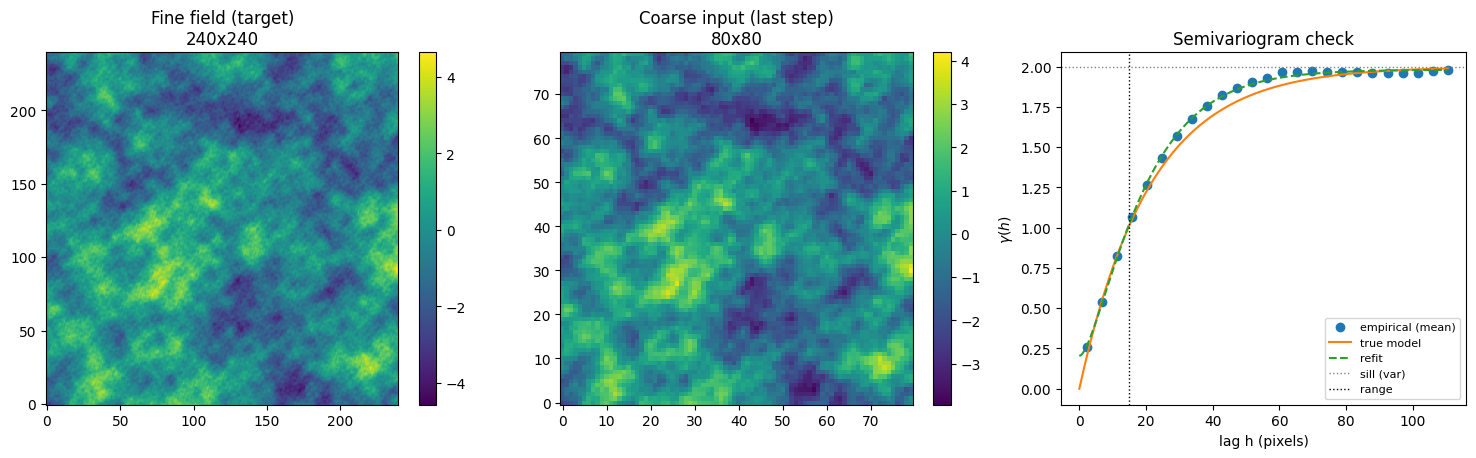

In [10]:
def plot_overview(cfg, coarse_stacks, fine_targets, bin_center, mean_gamma,
                  model, fit):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    im0 = axes[0].imshow(fine_targets[0], origin="lower", cmap="viridis")
    axes[0].set_title(f"Fine field (target)\n{fine_targets.shape[1]}x{fine_targets.shape[2]}")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(coarse_stacks[0, -1], origin="lower", cmap="viridis")
    c = coarse_stacks.shape[-1]
    axes[1].set_title(f"Coarse input (last step)\n{c}x{c}")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    axes[2].plot(bin_center, mean_gamma, "o", label="empirical (mean)")
    h = np.linspace(0, bin_center.max(), 200)
    axes[2].plot(h, model.variogram(h), "-", label="true model")
    axes[2].plot(h, fit.variogram(h), "--", label="refit")
    axes[2].axhline(cfg.var, color="grey", ls=":", lw=1, label="sill (var)")
    axes[2].axvline(cfg.len_scale, color="k", ls=":", lw=1, label="range")
    axes[2].set_xlabel("lag h (pixels)"); axes[2].set_ylabel(r"$\gamma(h)$")
    axes[2].set_title("Semivariogram check"); axes[2].legend(fontsize=8)

    plt.tight_layout(); plt.show()


plot_overview(check_cfg, coarse_stacks, fine_targets, bin_center, mean_gamma,
              true_model, fit_model)

## Save the dataset

Arrays saved for downstream model training (U-Net / VAE, with vs. without the
regularizer).

In [11]:
np.savez_compressed(
    "sim_dataset.npz",
    coarse_stacks=coarse_stacks,
    fine_targets=fine_targets,
    var=run_cfg.var, len_scale=run_cfg.len_scale, nu=run_cfg.nu,
    nugget=run_cfg.nugget, coarse_factor=run_cfg.coarse_factor,
)
print("saved -> sim_dataset.npz")

saved -> sim_dataset.npz


In [13]:
# ======================================================================
# Generate OOD (out-of-distribution) test datasets
# ----------------------------------------------------------------------
# These are SEPARATE structures from the training set, used to test whether
# the model (and the semivariogram penalty) generalizes to unseen spatial
# structure. The model is NEVER trained on these — only evaluated.
#
# Design principle: shift ONE structural axis at a time relative to the
# TRAINING config, so any performance change is attributable to that axis.
# Training structure (for reference): nu=0.5, len_scale=15, var=2.0
# ======================================================================

def make_ood_config(base: SimConfig, *, nu=None, len_scale=None, var=None,
                    n_samples=60, tag="") -> SimConfig:
    """Copy the base (training) config but override structural parameters
    to create an out-of-distribution test set. Only the params you pass are
    changed; everything else (grid size, coarse factor, stack depth) matches
    the training set so the comparison is clean."""
    from dataclasses import replace
    cfg = replace(
        base,
        nu=base.nu if nu is None else nu,
        len_scale=base.len_scale if len_scale is None else len_scale,
        var=base.var if var is None else var,
        n_samples=n_samples,
        seed=base.seed + 500_000,   # different seeds from training data
    )
    cfg._tag = tag  # informal label for bookkeeping
    return cfg


def build_and_save_ood(cfg: SimConfig, filename: str, check=True):
    """Build a test dataset from cfg, optionally sanity-check its structure,
    and save it with its true parameters (needed as ground truth later)."""
    cs, ft = build_dataset(cfg)
    print(f"{filename}: coarse {cs.shape}, fine {ft.shape} "
          f"| nu={cfg.nu}, len_scale={cfg.len_scale}, var={cfg.var}")
    if check:
        sanity_check_variogram(cfg, n_check=8)   # confirm structure is as requested
    np.savez_compressed(
        filename,
        coarse_stacks=cs, fine_targets=ft,
        var=cfg.var, len_scale=cfg.len_scale, nu=cfg.nu,
        nugget=cfg.nugget, coarse_factor=cfg.coarse_factor,
    )
    print(f"  saved -> {filename}\n")
    return cs, ft


# training config is the reference point
train_cfg = SimConfig()   # nu=0.5, len_scale=15, var=2.0

# --- Your two originally proposed test sets (both axes shifted) ---
ood_A = make_ood_config(train_cfg, nu=1.0, len_scale=12.0, n_samples=60, tag="nu1.0_ls12")
ood_B = make_ood_config(train_cfg, nu=1.5, len_scale=10.0, n_samples=60, tag="nu1.5_ls10")
ood_C = make_ood_config(train_cfg, nu=2.0, len_scale=25.0, n_samples=60, tag="nu2.0_ls25")


build_and_save_ood(ood_A, "ood_nu1.0_ls12.npz")
build_and_save_ood(ood_B, "ood_nu1.5_ls10.npz")
build_and_save_ood(ood_C, "ood_nu2.0_ls25.npz")


ood_nu1.0_ls12.npz: coarse (60, 3, 80, 80), fine (60, 240, 240) | nu=1.0, len_scale=12.0, var=2.0
--- Variogram sanity check ---
  requested : var=2.00  len_scale=12.00  nu=1.00
  recovered : var=1.82  len_scale=12.14  nu=1.70
  (averaged over 8 fields)
  saved -> ood_nu1.0_ls12.npz

ood_nu1.5_ls10.npz: coarse (60, 3, 80, 80), fine (60, 240, 240) | nu=1.5, len_scale=10.0, var=2.0
--- Variogram sanity check ---
  requested : var=2.00  len_scale=10.00  nu=1.50
  recovered : var=2.06  len_scale=11.62  nu=1.06
  (averaged over 8 fields)
  saved -> ood_nu1.5_ls10.npz

ood_nu2.0_ls25.npz: coarse (60, 3, 80, 80), fine (60, 240, 240) | nu=2.0, len_scale=25.0, var=2.0
--- Variogram sanity check ---
  requested : var=2.00  len_scale=25.00  nu=2.00
  recovered : var=2.25  len_scale=29.90  nu=1.59
  (averaged over 8 fields)
  saved -> ood_nu2.0_ls25.npz



(array([[[[-5.23445725e-01, -6.55478239e-01, -7.55313158e-01, ...,
            1.50863618e-01,  5.49963713e-02, -3.97291109e-02],
          [-5.93290448e-01, -7.31346667e-01, -8.45556259e-01, ...,
           -1.70827016e-01, -2.93566108e-01, -4.07804906e-01],
          [-6.46833539e-01, -7.85414934e-01, -9.10728872e-01, ...,
           -4.54346299e-01, -5.94474435e-01, -7.21784055e-01],
          ...,
          [ 1.94485199e+00,  1.75272036e+00,  1.55309463e+00, ...,
           -2.81063408e-01, -3.59130800e-01, -4.80221808e-01],
          [ 2.10353160e+00,  1.93823195e+00,  1.75740957e+00, ...,
           -1.81349814e-01, -2.84499645e-01, -4.33175772e-01],
          [ 2.27015352e+00,  2.13346195e+00,  1.97344530e+00, ...,
           -5.46056516e-02, -1.73596352e-01, -3.42565894e-01]],
 
         [[ 2.31466579e+00,  2.24365568e+00,  2.11225367e+00, ...,
            3.32247925e+00,  3.17814159e+00,  2.91258144e+00],
          [ 1.99811471e+00,  1.95111108e+00,  1.85702765e+00, ...,
     